# Load and clean all data ready for analysis:
>- LM PPD Data
>- OS Green Space
>- Trees outside woodlands
>- ROIFE
>- OS UPRN
>- Postcode to LSOA

In [1]:
import os
import time
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.validation import make_valid
import duckdb

In [2]:
os.environ['OGR_ORGANIZE_POLYGONS'] = 'SKIP' 
# Creates .db file in the project folder
conn = duckdb.connect(r"/Users/sammi/Dissertation2026/project.db")

# Create schemas to organize raw and clean data
#conn.execute("CREATE SCHEMA IF NOT EXISTS raw_data;")
#conn.execute("CREATE SCHEMA IF NOT EXISTS model_data;")

# Install and load the spatial extension
#conn.execute("INSTALL spatial;")
conn.execute("LOAD spatial;")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

# Retrieve data and store in db:
### Residential Transactions

In [ ]:
# Residential transactions data:
conn.execute("""
    CREATE TABLE IF NOT EXISTS raw_data.ppd_transactions AS
    SELECT 
        postcode,
        transactionid,
        price,
        dateoftransfer,
        propertytype,
        oldnew,
        duration,
        towncity,
        district,
        county,
        categorytype,
        lad23cd,
        CURRENT_ENERGY_RATING,
        PROPERTY_TYPE,
        BUILT_FORM,
        LOCAL_AUTHORITY_LABEL,
        CONSTITUENCY_LABEL,
        POSTTOWN,
        CONSTRUCTION_AGE_BAND,
        UPRN,
        TOTAL_FLOOR_AREA,
        priceper
    FROM read_csv_auto(
        '/Users/sammi/Dissertation2026/Data/Property Data/857911_bundle_2/857911_bundle_2/tranall_link_26122024/tranall_link_26122024.csv',
        strict_mode=false,
        max_line_size=10000000,
        delim=',',
        quote='"',
        escape='"',
        header=true
    )
""")

print(f"Transactions loaded: {conn.execute('SELECT COUNT(*) FROM raw_data.ppd_transactions').fetchone()[0]:,}")

### Postcode to LSOA:

In [ ]:
# Postcode to LSOA lookup:
conn.execute("""
    CREATE TABLE IF NOT EXISTS raw_data.postcode_to_lsoa AS
    SELECT * 
    FROM read_csv_auto(
        '/Users/sammi/Dissertation2026/Data/Peak Load Data/postcode_LSOA.csv',
        header=true,
        delim=',',
        quote='"',
        escape='"')
""")

print(f"Postcodes to LSOAs loaded: {conn.execute('SELECT COUNT(*) FROM raw_data.postcode_to_lsoa').fetchone()[0]:,}")

In [41]:
# IMD 2019:
conn.execute("""
    CREATE TABLE IF NOT EXISTS raw_data.IMD_2019 AS
    SELECT * 
    FROM read_csv_auto(
        '/Users/sammi/Dissertation2026/Data/Postcode_LSOA/IMD_2019_UK.csv',
        header=true,
        delim=',',
        quote='"',
        escape='"')
""")

print(f"IMD 2019 loaded: {conn.execute('SELECT COUNT(*) FROM raw_data.IMD_2019').fetchone()[0]:,}")

IMD 2019 loaded: 32,844


In [ ]:
# IMD 2019:
conn.execute("""
    CREATE TABLE IF NOT EXISTS raw_data.lsoa_2011_2022 AS
    SELECT * 
    FROM read_csv_auto(
        '/Users/sammi/Dissertation2026/Data/Postcode_LSOA/IMD_2019_UK.csv',
        header=true,
        delim=',',
        quote='"',
        escape='"')
""")

print(f"Lookups loaded: {conn.execute('SELECT COUNT(*) FROM raw_data.lsoa_2011_2022').fetchone()[0]:,}")

### OS Green Spaces:

In [4]:
# OS Green Space Data:
conn.execute("""
    CREATE TABLE IF NOT EXISTS raw_data.os_green_space AS
    SELECT * 
    FROM ST_Read(
        '/Users/sammi/Dissertation2026/Data/os_greenspace/GB_GreenspaceSite.shp')
""")
print(f"OS Green Space data loaded: {conn.execute('SELECT COUNT(*) FROM raw_data.os_green_space').fetchone()[0]:,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

OS Green Space data loaded: 165,978


### ROIFE:

In [ ]:
conn.execute("""
    CREATE TABLE raw_data.flood_outlines AS
    SELECT * FROM ST_Read('/Users/sammi/Dissertation2026/Data/Recorded_Flood_Outlines.gdb', layer='Recorded_Flood_Outlines')
""")

print(f"Flood Outlines data loaded: {conn.execute('SELECT COUNT(*) FROM raw_data.flood_outlines').fetchone()[0]:,}")

### OS UPRNs:

In [ ]:
# OS Unique Property Reference Number (UPRN) data:
conn.execute("""
    CREATE TABLE IF NOT EXISTS raw_data.os_uprn AS
    SELECT *
    FROM read_csv_auto(
        'osopenuprn_202606.csv',
        strict_mode=false,
        max_line_size=10000000,
        delim=',',
        quote='"',
        escape='"',
        header=true
    )
""")

print(f"UPRNs loaded: {conn.execute('SELECT COUNT(*) FROM raw_data.os_uprn').fetchone()[0]:,}")

# Load and Inspect Data:

## Property Transactions:

In [ ]:
# Join coordinates from OS UPRN data to PPD transactions data:
conn.execute("""
             CREATE TABLE IF NOT EXISTS raw_data.uppt AS
             SELECT 
             p.*,
             u.LATITUDE,
             u.LONGITUDE,
             u.X_COORDINATE,
             u.Y_COORDINATE
             FROM raw_data.ppd_transactions p
             LEFT JOIN raw_data.os_uprn u
             ON p.UPRN = u.UPRN
             """)

Count how many times each UPRN appears in the data, only keep UPRNs that occur 2 or more times for repeat sales sample. Add geometry from x and y coordinates, and create spatial index.

In [ ]:
conn.execute("""
             CREATE TABLE raw_data.repeats_geo AS
             WITH counted AS (
                 SELECT *,
                 COUNT(*) OVER (PARTITION BY UPRN) AS counts
                 FROM raw_data.uppt
                 ),
                 repeats AS (
                     SELECT * FROM counted
                     WHERE counts > 1
                     ),
                     repeats_clean AS (
                         SELECT * FROM repeats
                         WHERE UPRN IS NOT NULL
                         AND X_COORDINATE IS NOT NULL
                         AND Y_COORDINATE IS NOT NULL
                         )
                         SELECT *,
                         ST_Point(X_COORDINATE, Y_COORDINATE) AS geom
                         FROM repeats_clean
                         """)

conn.execute("CREATE INDEX transactions_idx ON raw_data.repeats_geo USING RTREE (geom)")

22,449,587 records. 92,501 with no UPRN. 94,181 with no coordinates. 11,329,028 unique properties.

There are 5,007,294 unique properties with only one sale. Keep only records where there are more than 1 sale, so keep 17,349,792 records. 

There are 5,355,402 that have consistent floor area values - these are most likely to have their features not change - we only keep the transactions associated with these UPRNs for consistent and accurate modelling.

After dropping properties with only one sale, there are no unidentified properties by UPRN - some NaNs are left - these are dropped and we are left with 17,125,098 properties.

In [ ]:
ppd_df['counts'] = ppd_df.groupby('UPRN')['UPRN'].transform('count')

print(len(ppd_df[ppd_df['counts'] > 1]))
print(len(ppd_df[ppd_df['counts'] == 1]))
repeats_df = ppd_df[ppd_df['counts'] > 1]
repeats_dff = repeats_df.dropna()

### Consistent UPRN features:
As a result, 14,388,316 out of 17,348,495 transactions are kept.

In [ ]:
print(conn.execute("""
                   SELECT COUNT(*) FROM (
                       SELECT UPRN
                       FROM raw_data.repeats_geo
                       GROUP BY UPRN
                       HAVING COUNT(DISTINCT TOTAL_FLOOR_AREA) = 1
                       AND COUNT(TOTAL_FLOOR_AREA) = COUNT(*)
                       )
                       """).fetchdf())


conn.execute("""
    CREATE TABLE raw_data.uprns_consistent AS
    SELECT UPRN
    FROM raw_data.repeats_geo
    GROUP BY UPRN
    HAVING COUNT(DISTINCT TOTAL_FLOOR_AREA) = 1
       AND COUNT(TOTAL_FLOOR_AREA) = COUNT(*)
""")

conn.execute("""
    CREATE TABLE raw_data.repeats_consistent_uprns AS
    SELECT * FROM raw_data.repeats_geo
    WHERE UPRN IN (SELECT UPRN FROM raw_data.uprns_consistent)
""")

print(conn.execute("SELECT COUNT(*) AS total_rows, COUNT(DISTINCT UPRN) AS unique_uprns FROM raw_data.repeats_consistent_uprns").fetchdf())
print(conn.execute("SELECT COUNT(*) AS total_rows, COUNT(DISTINCT UPRN) AS unique_uprns FROM raw_data.repeats_geo").fetchdf())

In [ ]:
# Load Flood Outlines data:
flood_outlines_df = conn.execute("""SELECT * EXCLUDE shape,
                            ST_AsText(shape) as geometry
                         FROM raw_data.flood_outlines""").df()



# Load postcode to lsoa lookup:
postcode_data = conn.execute("SELECT * FROM raw_data.postcode_to_lsoa").df()


## Adjust house prices to real 2024 values:

In [ ]:
hpi = pl.read_csv(r"/Users/sammi/Dissertation2026/data/UK-HPI-full-file-2025-10.csv")
hpi = hpi[['Date', 'RegionName', 'AreaCode', 'AveragePrice', 'Index', 'IndexSA' ]]

hpi = hpi.with_columns(pl.col('Date').str.to_date("%d/%m/%Y"))
hpi = hpi.with_columns(
    pl.col('Date').dt.strftime("%Y-%m").alias('year_month')
)
hpi = hpi.with_columns(pl.col('RegionName').str.to_uppercase())

repeats_df = pl.read_csv("repeats_df.csv", separator = ",")

county_matches_hpi = pl.read_csv("county_matches_hpi.csv")

repeats_df = repeats_df.with_columns(
    pl.col('county').str.to_uppercase()
).join(county_matches_hpi, on='county', how='left')

repeats_df = repeats_df.filter(pl.col('RegionName').is_not_null())

repeats_df = repeats_df.with_columns(
    pl.col('dateoftransfer').str.to_date().dt.strftime('%Y-%m').alias('year_month')
)

# Index at the time of purchase, per region/month
index_at_purchase = hpi.select(['RegionName', 'year_month', 'Index']).rename({'Index': 'index_at_purchase'})

repeats_df = repeats_df.join(index_at_purchase, on=['RegionName', 'year_month'], how='left')

# Index for the base period (December 2024), per region
index_dec_2024 = (
    hpi.filter(pl.col('year_month') == '2024-12')
    .select(['RegionName', 'Index'])
    .rename({'Index': 'index_dec_2024'})
)

repeats_df = repeats_df.join(index_dec_2024, on='RegionName', how='left')

# Calculate real price of transaction:
repeats_df = repeats_df.with_columns(
    (pl.col('price') * (pl.col('index_dec_2024') / pl.col('index_at_purchase'))).alias('real_price_dec_2024')
)

repeats_df.to_csv("repeats_df_real_prices.csv", separator = ",")

## Flood Outlines:
31,696 distinct outlines. After filtering for only flood lines between 1995 and 2024, and keeping only high quality flood outlines - only keep records that are "considered and accepted" in the hfm_status column. 15,205 outlines are kept.

In [ ]:
conn.execute("CREATE INDEX flood_outlines_idx ON raw_data.flood_outlines_clean USING RTREE (shape)")

In [ ]:
conn.execute("""CREATE TABLE IF NOT EXISTS raw_data.flood_outlines_filtered AS
             SELECT * FROM raw_data.flood_outlines_clean
             WHERE hfm_status IN ('considered and accepted')""")

# Match UPRNs to Flood Outlines:
## Spatial join UPRNs to flood outlines to find which properties are *within* known flood outlines.

In [ ]:
# Get flood outlines and distinct UPRNs:
flood_outlines_df = conn.execute("""SELECT * EXCLUDE shape,
                            ST_AsText(shape) as geometry
                         FROM raw_data.flood_outlines_filtered""").fetchdf()

uprns = conn.execute("""SELECT * EXCLUDE geom,
                            ST_AsText(geom) as geometry
                         FROM raw_data.uprns_consistent
                         """).fetchdf()

flood_outlines_gdf = gpd.GeoDataFrame(flood_outlines_df, geometry=gpd.GeoSeries.from_wkt(flood_outlines_df['geometry']), crs='EPSG:27700')
uprns_gdf = gpd.GeoDataFrame(uprns, geometry=gpd.GeoSeries.from_wkt(uprns['geometry']), crs='EPSG:27700')

print(f"Length of flood outlines: {len(flood_outlines_gdf)}")
print(f"Length of UPRNs: {len(uprns_gdf)}")

start = time.time()
# Join flood outlines to eahc uprn based on whether uprn is located within a flood outline:
matched_gdf = gpd.sjoin(
    uprns_gdf,
    flood_outlines_gdf,
    how='inner',
    predicate='within'
)

print(f"Matched geometries:\n{matched_gdf.head()}")

print(f"Length of matched geometries: \n{len(matched_gdf)}")
end = time.time()
print(f"Time taken: {end - start} seconds")

print(len(matched_gdf))
print(matched_gdf['UPRN'].nunique())

# Save file:
matched_gdf.to_file("/Users/sammi/Dissertation2026/Data/uprn_flood_matches.geojson", driver="GeoJSON")

## Create new table of flood matched UPRNs: 27,029 unique properties have transactions before or after a flood.

In [ ]:
conn.execute("""
    CREATE TABLE raw_data.uprn_flood_matches AS
    SELECT * FROM ST_Read('/Users/sammi/Dissertation2026/Data/uprn_flood_matches.geojson')
""")

print(f"Matched UPRNs data loaded: {conn.execute('SELECT COUNT(*) FROM raw_data.uprn_flood_matches').fetchone()[0]:,}")

print(conn.execute("SELECT * FROM raw_data.uprn_flood_matches LIMIT 5").fetchdf())

Create a new table where each transaction is matched to a flood based on the uprn:

In [ ]:
conn.execute("""
    CREATE TABLE raw_data.transactions_flood_matched AS
    SELECT
        t.*,
        m.*
    FROM raw_data.repeats_geo t
    LEFT JOIN raw_data.uprn_flood_matches m
      ON t.UPRN = m.UPRN
""")

### 17259045 transactions with 10975461 transaction pairs. After controlling for accurate UPRNS, there are 5,272,193 unique properties, with 8,889,738 distinct transactions. Of whice, 10,379 unique transactions that are sold before and after a flood - bracketed properties - that are located on a flood zone.

In [ ]:
df = pl.read_csv("repeats_df_real_prices.csv",separator = ",")

df = df[['UPRN', 'dateoftransfer', 'transactionid', 'price', 'start_date', 'end_date','county','RegionName','real_price_dec_2024']]
df = df.sort(['UPRN', 'dateoftransfer'])

# Shift prices down to compare transactions:
df = df.with_columns([
    pl.col('dateoftransfer').shift(1).over('UPRN').alias('transfer_data_shifted'),
    pl.col('real_price_dec_2024').shift(1).over('UPRN').alias('real_price_2024_shifted'),
])

transaction_pairs = df.filter(pl.col('transfer_date_shifted').is_not_null())

# Find which transactions come before and after a flood event - i.e. sales bracket a flood event:
transaction_pairs = transaction_pairs.with_columns(
    ((pl.col('start_date') >= pl.col('transfer_date_shifted')) & (pl.col('start_date') <= pl.col('dateoftransfer')))
    .cast(pl.Int8)
    .alias('flood_bracket')
)

print(transaction_pairs.select(pl.sum("flood_bracket")))

# Calculate price differentials. Join attributes and save to model_data scheme:

In [ ]:
transaction_pairs = transaction_pairs.filter(pl.col('real_price_2024_shifted').is_not_null())

# Log of first sale price:
transaction_pairs = transaction_pairs.with_columns(
    pl.col("real_price_dec_2024").log()
    .alias('real_price_dec_2024_log')
)

# Log of subsequent sale price:
transaction_pairs = transaction_pairs.with_columns(
    pl.col("real_price_2024_shifted").log()
    .alias('real_price_2024_shifted_log')
)

# Real price difference:
transaction_pairs = transaction_pairs.with_columns(
    (pl.col('real_price_dec_2024') - pl.col('real_price_2024_shifted')).alias('price_diff')
)

# Log price difference:
transaction_pairs = transaction_pairs.with_columns(
    (pl.col('real_price_dec_2024_log') - pl.col('real_price_2024_shifted_log')).alias('log_price_diff')
)

# Get property attributes for each UPRN:
property_attrs = conn.execute("""
    SELECT DISTINCT ON (UPRN)
        UPRN, TOTAL_FLOOR_AREA, postcode, propertytype, oldnew, duration, categorytype, lad23cd,
        CURRENT_ENERGY_RATING, PROPERTY_TYPE, BUILT_FORM, CONSTRUCTION_AGE_BAND,
        LATITUDE, LONGITUDE, X_COORDINATE, Y_COORDINATE, counts,
        ST_AsText(geom) AS geom
    FROM raw_data.transactions_flood_matched
""").pl()

# Join attributes onto each property via UPRN and store new data under model_data scheme
transaction_pairs = transaction_pairs.join(property_attrs, on='UPRN', how='left')
conn.execute("CREATE OR REPLACE TABLE model_data.uppt_transactions AS SELECT * FROM transaction_pairs")
print(conn.execute("SELECT COUNT(*) FROM model_data.uppt_transactions").fetchone()[0])

## Keep only transactions where the UPRN has consistent features:

In [ ]:
conn.execute(""" CREATE TABLE model_data.uppt_transactions_consistent_transactions AS
             SELECT * FROM model_data.uppt_transactions
             WHERE UPRN IN (SELECT UPRN FROM raw_data.uprns_consistent)
             """)

# Buffer Flood Outlines:
There are 15,205 flood outlines that have been considered and accepted. However, there are some duplicates, 14 rows are duplicates. These are checked to ensure they are actual duplicates, i.e. same start date/ end dat, same geometry - they are all true duplicates and are deleted from the dataset - keeping the first row of each.

In [163]:
# Get flood outlines and distinct UPRNs:
flood_outlines_df = conn.execute("""SELECT * EXCLUDE shape,
                            ST_AsText(shape) as geometry
                         FROM raw_data.flood_outlines_filtered""").fetchdf()

flood_outlines_gdf = gpd.GeoDataFrame(flood_outlines_df, geometry=gpd.GeoSeries.from_wkt(flood_outlines_df['geometry']), crs='EPSG:27700')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [164]:
print(flood_outlines_gdf['rec_out_id'].nunique(), len(flood_outlines_gdf))
flood_outlines_gdf = flood_outlines_gdf.drop_duplicates(subset='rec_out_id', keep='first')

15191 15205


In [169]:
total_area_sqm = flood_outlines_gdf.geometry.area.sum()
print(total_area_sqm/1e6)

4413.298689065498


### Some flood outline geometries are invalid, they are checked and made valid using Shapely. The outlines are then simplified to a tolerance of 10m to maintain computational efficiency.

In [178]:
# Step 1: fix validity on the ORIGINAL geometry first
flood_outlines_gdf['geometry_valid'] = flood_outlines_gdf['geometry'].apply(
    lambda g: make_valid(g) if not g.is_valid else g
)

# Step 2: confirm all 1,352 are now fixed
print((~flood_outlines_gdf['geometry_valid'].is_valid).sum())  # should be 0

# Step 3: simplify the now-valid geometry
flood_outlines_gdf['geometry_simplified'] = flood_outlines_gdf['geometry_valid'].simplify(tolerance=10, preserve_topology=True)

# Step 4: re-check validity after simplification (simplify can occasionally reintroduce issues, though rare on already-valid input)
flood_outlines_gdf['geometry_simplified'] = flood_outlines_gdf['geometry_simplified'].apply(
    lambda g: make_valid(g) if not g.is_valid else g
)

print((~flood_outlines_gdf['geometry_simplified'].is_valid).sum())

0
0


In [187]:
print(flood_outlines_gdf['rec_out_id'].nunique() == len(flood_outlines_gdf))
print(len(flood_outlines_gdf))

True
15191


### The 1000m buffer zone is then applied, and a border zone around each flood is created to capture properties that are located near a flood, but never within an outline. These are used as a control group.

In [188]:
flood_outlines_gdf['buffer_1000m'] = flood_outlines_gdf['geometry_simplified'].buffer(1000)
flood_outlines_gdf['border_zone'] = flood_outlines_gdf['buffer_1000m'].difference(flood_outlines_gdf['geometry_simplified'])

In [ ]:
border_zones_gdf = flood_outlines_gdf[['rec_out_id', 'border_zone', 'buffer_1000m', 'geometry_simplified']].set_geometry('border_zone')
border_zones_gdf = border_zones_gdf.set_crs('EPSG:27700') 

#border_zones_gdf.to_file("/Users/sammi/Dissertation2026/Data/flood_buffers_outlines.geojson", driver = 'GeoJSON')

<Axes: >

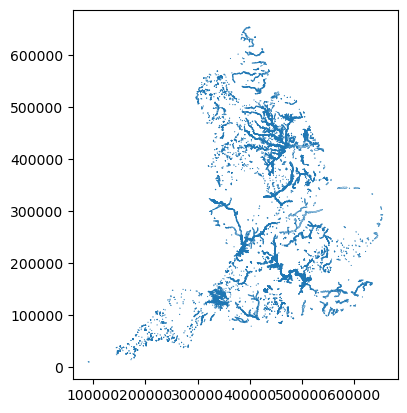

In [200]:
border_zones_gdf.plot()

## Match border zones to UPRNs:

In [24]:
uprns = conn.execute("""SELECT * EXCLUDE geom,
                            ST_AsText(geom) as geometry
                         FROM raw_data.unique_properties
                         """).fetchdf()
uprns_gdf = gpd.GeoDataFrame(uprns, geometry=gpd.GeoSeries.from_wkt(uprns['geometry']), crs='EPSG:27700')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
border_zones_gdf = flood_outlines_gdf[['rec_out_id', 'border_zone']].set_geometry('border_zone')
border_zones_gdf = border_zones_gdf.set_crs('EPSG:27700') 

control_properties = gpd.sjoin(uprns_gdf,
                               border_zones_gdf,
                               how='inner',
                               predicate='within'
                               )

print(len(control_properties))
print(control_properties['UPRN'].nunique())

control_properties = control_properties.merge(
    flood_outlines_gdf[['rec_out_id', 'start_date', 'end_date']].rename(
        columns={'start_date': 'flood_start', 'end_date': 'flood_end'}
    ),
    on='rec_out_id',
    how='left'
)
print(len(control_properties))
print(control_properties['UPRN'].nunique())

In [53]:
# Send border control properties to db:
conn.register('control_properties_df', control_properties.drop(columns='geometry'))

conn.execute("""
    CREATE TABLE raw_data.control_properties AS
    SELECT * FROM control_properties_df
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### Get border control properties and merge with transactions data to get a final model dataset that comprises of control properties located in 1000m border zones and properties actually located within flood zones. All transactions are bracketed such that we can identify properties that are sold before and after a flood.

In [4]:
# Remove nulls for border zone analysis:
uprn_transactions = conn.execute("""
    SELECT * FROM model_data.uppt_transactions_consistent_transactions
    WHERE start_date IS NOT NULL
""").pl()

flood_bracket_uprns = uprn_transactions.filter(pl.col('flood_bracket') == 1).select('UPRN').unique()
print(len(flood_bracket_uprns))

print(len(uprn_transactions))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

10302


In [ ]:
control_properties = conn.execute("SELECT * FROM raw_data.control_properties").pl()

### Remove any UPRNs from the controls that are already found to be actual flood zone bracketed.

In [7]:
control_properties_clean = control_properties.join(
    flood_bracket_uprns,
    on='UPRN',
    how='anti'
)

### Join transactions data onto border control properties:

In [ ]:
control_transactions = uprn_transactions.join(
    control_properties_clean,
    on='UPRN',
    how='inner'
)

control_transactions = control_transactions.with_columns(
    pl.col('flood_start').dt.to_string("%Y-%m-%d"),
    pl.col('flood_end').dt.to_string("%Y-%m-%d")
)

### Find which properties have sales that bracket the flood that they are in the border zone of.

In [ ]:
control_transactions = control_transactions.with_columns(
    ((pl.col('flood_start') >= pl.col('transfer_date_shifted')) & (pl.col('flood_start') <= pl.col('dateoftransfer')))
    .cast(pl.Int8)
    .alias('border_zone_bracket')
)

print(len(control_transactions.filter(pl.col('border_zone_bracket')==1)))

In [ ]:
control_transactions = control_transactions.drop('flood_bracket')
control_transactions = control_transactions.drop('index_right')
control_transactions = control_transactions.drop('end_date')
control_transactions = control_transactions.drop('start_date')
control_transactions = control_transactions.drop('in_flood_zone')
# Might need to add this back in later
control_transactions = control_transactions.drop('rec_out_id')

control_transactions = control_transactions.with_columns(
    pl.lit(1).cast(pl.Int8).alias('in_border_zone')
).rename({'border_zone_bracket': 'flood_bracket'})

There are 330,135 transaction in the border zone of a flood, of which 26,402 transactions where a control property has sales that bracket the flood outline.

In [ ]:
print(len(control_transactions.filter(pl.col('in_border_zone')==1)))
print(len(control_transactions.filter(pl.col('flood_bracket')==1)))

No properties within an actual flood zone are in the border zone.

In [ ]:
uprn_transactions = uprn_transactions.with_columns(pl.lit(0).cast(pl.Int8).alias('in_border_zone'))

uprn_transactions = uprn_transactions.rename({
    'start_date': 'flood_start',
    'end_date': 'flood_end'
})

In [17]:
column_order = [
    'UPRN', 'dateoftransfer', 'transactionid', 'price', 'flood_start', 'flood_end',
    'county', 'RegionName', 'real_price_dec_2024', 'transfer_date_shifted',
    'real_price_2024_shifted', 'flood_bracket', 'real_price_dec_2024_log',
    'real_price_2024_shifted_log', 'price_diff', 'log_price_diff', 'postcode',
    'propertytype', 'oldnew', 'duration', 'categorytype', 'lad23cd',
    'CURRENT_ENERGY_RATING', 'PROPERTY_TYPE', 'BUILT_FORM', 'CONSTRUCTION_AGE_BAND',
    'LATITUDE', 'LONGITUDE', 'X_COORDINATE', 'Y_COORDINATE', 'counts', 'geom',
    'in_flood_zone', 'in_border_zone'
]

treated_transactions = uprn_transactions.select(column_order)
control_transactions = control_transactions.select(column_order)

border_zone_model_data = pl.concat([treated_transactions, control_transactions], how='vertical_relaxed')

In [ ]:
conn.register('border_zone_model_data_temp', border_zone_model_data) 

conn.execute("""
    CREATE TABLE model_data.border_bracket_uppt_transactions AS
    SELECT * EXCLUDE (geom), ST_GeomFromText(geom) AS geom
    FROM border_zone_model_data_temp
""")

conn.unregister('border_zone_model_data_temp')

In [ ]:
print(conn.execute("SELECT COUNT(*) FROM model_data.border_bracket_uppt_transactions").fetchdf())
print(conn.execute("DESCRIBE model_data.border_bracket_uppt_transactions").fetchdf())

# OS Green Space Layer
There are 165,978 different green areas from the OS green space layer. After filtering for the my hyrodoligcally relevant green spaces, there are 83,898 green areas left - these are comprised of public parks or gardens, allotments, golf courses, and play sapces. These are chosen as they are more likely to attenuate flood water due to being made up of trees, grasses, etc and therefore most relevant to the research question.

In [ ]:
greenspace_df = conn.execute("""SELECT * 
                            EXCLUDE geom, ST_AsText(geom) as geometry
                             FROM raw_data.os_green_space""").fetchdf()

greenspace_gdf = gpd.GeoDataFrame(greenspace_df, geometry=gpd.GeoSeries.from_wkt(greenspace_df['geometry']), crs='EPSG:27700')

In [31]:
greenspace_gdf = greenspace_gdf[greenspace_gdf['function'].isin(["Public Park Or Garden", "Allotments Or Community Growing Spaces","Golf Course", "Play Space"])]

## Correct for invalid greenspace polygons:
As with the flood outlines, the greenspaces are validity-checked and simplified to a tolerance of 50m to ensure that operations are computationally efficient.

In [ ]:
# Step 1: validate individual geometries
greenspace_gdf['geometry_valid'] = greenspace_gdf['geometry'].apply(lambda g: make_valid(g) if not g.is_valid else g)
print((~greenspace_gdf['geometry_valid'].is_valid).sum())

# Step 2: dissolve the validated geometries
dissolved_geom = greenspace_gdf['geometry_valid'].union_all()

# Step 3: validate the dissolved result
if not dissolved_geom.is_valid:
    dissolved_geom = make_valid(dissolved_geom)

# Step 4: simplify on the single combined geometry
dissolved_geom_simplified = dissolved_geom.simplify(tolerance=50, preserve_topology=True)

# Step 5: re-validate after simplification
if not dissolved_geom_simplified.is_valid:
    dissolved_geom_simplified = make_valid(dissolved_geom_simplified)

greenspaces = gpd.GeoDataFrame(geometry=[dissolved_geom_simplified], crs='EPSG:27700')

0


In [ ]:
greenspace_wkt = dissolved_geom_simplified.wkt

greenspace_df = pd.DataFrame({'geom_wkt': [greenspace_wkt]})
conn.register('greenspace_wkt_temp', greenspace_df)

conn.execute("""
    CREATE TABLE model_data.greenspace_dissolved AS
    SELECT ST_GeomFromText(geom_wkt) AS geom
    FROM greenspace_wkt_temp
""")
conn.unregister('greenspace_wkt_temp')

### UPRN 200m buffers

In [ ]:
conn.execute("""CREATE TABLE model_data.uprn_buffers AS
             SELECT * FROM raw_data.uprn_buffers
             WHERE UPRN IN (SELECT UPRN FROM model_data.border_bracket_uppt_transactions)
             """)

## Calculate intersection area between buffers and green spaces:

Create greenspaces as one layer to make the spatial operations easier.

In [ ]:
conn.execute("""
    CREATE OR REPLACE TABLE model_data.greenspace_dissolved_parts AS
    SELECT UNNEST(ST_Dump(geom)).geom AS geom
    FROM model_data.greenspace_dissolved
""")

conn.execute("CREATE INDEX greenspace_parts_idx ON model_data.greenspace_dissolved_parts USING RTREE (geom)")

conn.execute("SELECT COUNT(*) FROM model_data.greenspace_dissolved_parts").fetchdf()

Spatial join on intersection between buffer areas and greenspaces to calculate proportion of buffer area with green space. Include all UPRNs - even those with null greenspace area.

In [ ]:
conn.execute("""
    CREATE TABLE model_data.greenspace_coverage AS
    SELECT
        b.UPRN,
        SUM(ST_Area(ST_Intersection(b.buffer_geom, g.geom))) AS greenspace_area,
        ST_Area(b.buffer_geom) AS buffer_area,
        SUM(ST_Area(ST_Intersection(b.buffer_geom, g.geom))) / ST_Area(b.buffer_geom) AS greenspace_proportion
    FROM model_data.uprn_buffers b
    JOIN model_data.greenspace_dissolved_parts g
      ON ST_Intersects(b.buffer_geom, g.geom)
    GROUP BY b.UPRN, b.buffer_geom
""")

conn.execute("""
    CREATE TABLE model_data.greenspace_coverage_all_uprns AS
    SELECT
        b.UPRN,
        COALESCE(gc.greenspace_area, 0) AS greenspace_area,
        ST_Area(b.buffer_geom) AS buffer_area,
        COALESCE(gc.greenspace_proportion, 0) AS greenspace_proportion
    FROM model_data.uprn_buffers b
    LEFT JOIN model_data.greenspace_coverage gc ON b.UPRN = gc.UPRN
""")

### Join transactions dataset to greenspace proportions based on UPRN:
In total there are 22,193 distinct UPRNs in the transactions set and each of them are matched to a corresponding GI proportion:

In [ ]:
uprn_GI_prop = conn.execute("SELECT * FROM model_data.greenspace_coverage_all_uprns").fetchdf()
uprn_BBT = conn.execute("SELECT * FROM model_data.border_bracket_uppt_transactions").fetchdf()

conn.execute("""
    CREATE OR REPLACE TABLE model_data.uppt_bracket_GI AS
    SELECT u.*, e.*
    FROM model_data.border_bracket_uppt_transactions u
    LEFT JOIN model_data.greenspace_coverage_all_uprns e
      ON u.UPRN = e.UPRN
""")

In [ ]:
print(conn.execute("SELECT COUNT(*) FROM model_data.uppt_bracket_GI").fetchdf())
print(len(uprn_GI_prop))
print(uprn_BBT['UPRN'].nunique())

   count_star()
0        382775


### Save table to model_data schema:

# Add controls for elevation and socio-economic factors:
Elevation is set according to OS Terrain 50:

In [ ]:
uprns_elevation = gpd.read_file("/Users/sammi/Dissertation2026/Data/final_uprns_elevation.geojson")

print(uprns_elevation.head())

conn.register('uprn_elevations', uprns_elevation.drop(columns='geometry'))

conn.execute("""
    CREATE OR REPLACE TABLE model_data.uppt_bracket_GI_Controls AS
    SELECT u.*, e.Z
    FROM model_data.uppt_bracket_GI u
    LEFT JOIN uprn_elevations e
      ON u.UPRN = e.UPRN
""")

conn.unregister('uprn_elevations')

result = conn.execute("SELECT COUNT(*) FROM model_data.uppt_bracket_GI_Controls ").fetchdf()
print(result)

### For IMD, first match postcodes to LSOA2021. However, 2019 IMD uses 2011 LSOAs, match 2021 LSOA codes to 2011. Then merge income data from IMD 2019.

In [15]:
conn.execute("""
    CREATE OR REPLACE TABLE model_data.uppt_bracket_GI_Controls AS
    SELECT u.*, l.pcds, l.lsoa21cd
    FROM model_data.uppt_bracket_GI_Controls u
    LEFT JOIN raw_data.postcode_to_lsoa l
      ON u.postcode = l.pcds
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
ee = conn.execute("SELECT COUNT(*) FROM model_data.uppt_bracket_GI_Controls ").fetchdf()
print(ee)

   count(DISTINCT UPRN)
0                     0


In [ ]:
conn.execute("""
    CREATE OR REPLACE TABLE model_data.uppt_bracket_GI_Controls AS
    SELECT u.*, l.LSOA11CD
    FROM model_data.uppt_bracket_GI_Controls u
    LEFT JOIN raw_data.lsoa_2011_2022 l
      ON u.lsoa21cd = l.LSOA21CD
""")

conn.execute("""
    CREATE OR REPLACE TABLE model_data.uppt_bracket_GI_Controls AS
    SELECT u.*, p."LSOA code (2011)", p."Income Decile (where 1 is most deprived 10% of LSOAs)"
    FROM model_data.uppt_bracket_GI_Controls u
    LEFT JOIN raw_data.IMD_2019 p
      ON u.LSOA11CD = p."LSOA code (2011)"
""")

print(conn.execute(""" SELECT COUNT(DISTINCT UPRN) FROM model_data.uppt_bracket_GI_Controls
                   WHERE "Income Decile (where 1 is most deprived 10% of LSOAs)" IS NULL
                   """).fetchdf())

## Add floor area:

In [ ]:
conn.execute("""
    CREATE OR REPLACE TABLE model_data.uppt_bracket_GI_Controls AS
    SELECT u.*, p.TOTAL_FLOOR_AREA
    FROM model_data.uppt_bracket_GI_Controls u
    LEFT JOIN (
        SELECT UPRN, MAX(TOTAL_FLOOR_AREA) AS TOTAL_FLOOR_AREA
        FROM raw_data.transactions_flood_matched
        GROUP BY UPRN
    ) p
      ON u.UPRN = p.UPRN
    WHERE u.UPRN IN (SELECT UPRN FROM raw_data.uprns_consistent)
""")

## Load updated dataset:
Need to figure out why there are 2 million records - up from around 390,000.

Need to also assess flood history - groupby UPRN and count flood_bracket == 1.

Get years from date and cast as int.

In [ ]:
df = conn.execute(""" SELECT * 
                  EXCLUDE geom, ST_AsText(geom) as geometry
                  FROM model_data.uppt_bracket_GI_Controls
                   """).pl()
print(len(df))
df.null_count()
df.is_duplicated().sum()

387702


UPRN,dateoftransfer,transactionid,price,flood_start,flood_end,county,RegionName,real_price_dec_2024,transfer_date_shifted,real_price_2024_shifted,flood_bracket,real_price_dec_2024_log,real_price_2024_shifted_log,price_diff,log_price_diff,postcode,propertytype,oldnew,duration,categorytype,lad23cd,CURRENT_ENERGY_RATING,PROPERTY_TYPE,BUILT_FORM,CONSTRUCTION_AGE_BAND,LATITUDE,LONGITUDE,X_COORDINATE,Y_COORDINATE,counts,in_flood_zone,in_border_zone,UPRN_1,greenspace_area,buffer_area,greenspace_proportion,Z,pcds,lsoa21cd,LSOA11CD,LSOA code (2011),Income Decile (where 1 is most deprived 10% of LSOAs),TOTAL_FLOOR_AREA,geometry
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2615,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [143]:
dff_unique = df.unique(keep='first')
dff_unique = dff_unique.sort(by = ['UPRN', 'dateoftransfer'])

### There are 123,253 transaction pairs in the final dataset, from 22,193 UPRNs. There are 10,302 UPRNs that have transactions that bracket a flood and are located in a known flood zone.

In [176]:
print(len(dff_unique))

123253


In [177]:
print(dff_unique['UPRN'].n_unique())

print(dff_unique.group_by(['in_border_zone', 'flood_bracket']).agg(pl.len()))
print(dff_unique.group_by(['in_border_zone', 'flood_bracket']).agg(pl.col("UPRN").n_unique().alias("n_unique_uprns")))

22193
shape: (4, 3)
┌────────────────┬───────────────┬───────┐
│ in_border_zone ┆ flood_bracket ┆ len   │
│ ---            ┆ ---           ┆ ---   │
│ i8             ┆ i8            ┆ u32   │
╞════════════════╪═══════════════╪═══════╡
│ 0              ┆ 0             ┆ 41549 │
│ 0              ┆ 1             ┆ 10568 │
│ 1              ┆ 1             ┆ 8415  │
│ 1              ┆ 0             ┆ 62721 │
└────────────────┴───────────────┴───────┘
shape: (4, 3)
┌────────────────┬───────────────┬────────────────┐
│ in_border_zone ┆ flood_bracket ┆ n_unique_uprns │
│ ---            ┆ ---           ┆ ---            │
│ i8             ┆ i8            ┆ u32            │
╞════════════════╪═══════════════╪════════════════╡
│ 1              ┆ 0             ┆ 9717           │
│ 1              ┆ 1             ┆ 4296           │
│ 0              ┆ 0             ┆ 18752          │
│ 0              ┆ 1             ┆ 10302          │
└────────────────┴───────────────┴────────────────┘


In [179]:
model_df = dff_unique

In [205]:
model_df.head(0)

UPRN,dateoftransfer,transactionid,price,flood_start,flood_end,county,RegionName,real_price_dec_2024,transfer_date_shifted,real_price_2024_shifted,flood_bracket,real_price_dec_2024_log,real_price_2024_shifted_log,price_diff,log_price_diff,postcode,propertytype,oldnew,duration,categorytype,lad23cd,CURRENT_ENERGY_RATING,PROPERTY_TYPE,BUILT_FORM,CONSTRUCTION_AGE_BAND,LATITUDE,LONGITUDE,X_COORDINATE,Y_COORDINATE,counts,in_flood_zone,in_border_zone,UPRN_1,greenspace_area,buffer_area,greenspace_proportion,Z,pcds,lsoa21cd,LSOA11CD,LSOA code (2011),IMD_Income_Dec_2019,TOTAL_FLOOR_AREA,geometry,year_t,year_v,n_floods_history,flood_start_,flood_end_,flood_duration,flood_duration_days
i64,str,str,i64,str,str,str,str,f64,str,f64,i8,f64,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,f64,f64,f64,f64,i64,i8,i8,i64,f64,f64,f64,f64,str,str,str,str,f64,f64,str,f64,f64,u32,datetime[μs],datetime[μs],duration[μs],i64


In [206]:
model_df[['UPRN', 'dateoftransfer', 'flood_start', 'flood_end', 'real_price_dec_2024',	'transfer_date_shifted'	,'real_price_2024_shifted',
          'flood_bracket', 'log_price_diff', 'propertytype', 'PROPERTY_TYPE',	'BUILT_FORM', 'in_flood_zone', 'in_border_zone',
          'greenspace_area',	'buffer_area',	'greenspace_proportion', 'Z', 'TOTAL_FLOOR_AREA', 'IMD_Income_Dec_2019'         
          ]].write_csv("model_df.csv")

In [180]:
# Year of initial sale
model_df = model_df.with_columns(
    year_t = (pl.col('transfer_date_shifted').str.to_datetime("%Y-%m-%d").dt.year())
)

# Year of post sale
model_df = model_df.with_columns(
    year_v = (pl.col('dateoftransfer').str.to_datetime("%Y-%m-%d").dt.year())
)

In [ ]:
# Calculate number of floods for bracketed properties in flood zones:
flood_counts = model_df.group_by("UPRN").agg(
    ((pl.col("flood_bracket") == 1) & (pl.col("in_border_zone") == 0)).sum().alias("n_floods_history")
)
print(flood_counts)
model_df = model_df.join(flood_counts, on="UPRN", how="left")

In [182]:
model_df = model_df.rename({"Income Decile (where 1 is most deprived 10% of LSOAs)": "IMD_Income_Dec_2019"})

In [183]:
# Calculate flood duration for bracketed properties in flood zones:
model_df = model_df.with_columns([
    pl.col("flood_start").str.to_datetime(strict=False).alias("flood_start_"),
    pl.col("flood_end").str.to_datetime(strict=False).alias("flood_end_"),
])

model_df = model_df.with_columns(
    flood_duration = pl.when((pl.col("flood_bracket") == 1) & (pl.col("in_border_zone") == 0))
        .then(pl.col("flood_end_") - pl.col("flood_start_"))
        .otherwise(None)
)

model_df = model_df.with_columns(
    flood_duration_days = pl.col("flood_duration").dt.total_days()
)

In [184]:
model_df = model_df.with_columns([
    pl.col('year_t').cast(pl.Float64),
    pl.col('year_v').cast(pl.Float64),
    pl.col('IMD_Income_Dec_2019').cast(pl.Float64)
])

In [185]:
x_cols = ['real_price_dec_2024', 'log_price_diff', 'year_t', 'year_v',
          'TOTAL_FLOOR_AREA', 'greenspace_area', 'greenspace_proportion', 'Z',
          'IMD_Income_Dec_2019', 'n_floods_history', 'flood_duration', 'flood_start']

In [186]:
model_df[x_cols].describe()

statistic,real_price_dec_2024,log_price_diff,year_t,year_v,TOTAL_FLOOR_AREA,greenspace_area,greenspace_proportion,Z,IMD_Income_Dec_2019,n_floods_history,flood_duration,flood_start
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""count""",123253.0,123253.0,123253.0,123253.0,123253.0,123253.0,123253.0,123253.0,123253.0,123253.0,"""10568""","""123253"""
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""112685""","""0"""
"""mean""",302967.415948,-0.017543,2006.373938,2010.969615,84.625063,3745.64379,0.029999,41.2124,6.205123,0.237625,"""18 days, 23:24:42.513247""",null
"""std""",250767.73408,0.231811,7.267495,7.801364,43.720524,8636.731832,0.069173,35.920435,2.402359,0.456142,null,null
"""min""",10177.083333,-2.829747,1995.0,1995.0,0.0,0.0,0.0,-3.750788,1.0,0.0,"""0:00:00""","""1995-01-20"""
"""25%""",167652.236652,-0.092159,2001.0,2004.0,58.0,0.0,0.0,13.2456,4.0,0.0,"""1 day, 0:00:00""",null
"""50%""",239400.0,0.0,2005.0,2011.0,74.0,98.677492,0.00079,26.7956,6.0,0.0,"""3 days, 0:00:00""",null
"""75%""",363172.043011,0.039881,2012.0,2018.0,99.0,2705.493758,0.021669,59.855521,8.0,0.0,"""10 days, 0:00:00""",null
"""max""",8.1804e6,2.872059,2024.0,2024.0,907.0,99969.958901,0.80067,333.316606,10.0,4.0,"""367 days, 0:00:00""","""2024-12-05"""
